In [1]:
import sys

print(sys.executable)

c:\Users\trasn\OneDrive\Dokumente\programing\adc-downstream-process-development\.venv\Scripts\python.exe


# ADC Downstream Process Design

## Project objective

This notebook defines the scientific and process-development framework for a
hypothetical post-conjugation antibody-drug conjugate (ADC) purification
campaign.

The goal is to develop a data-driven downstream purification strategy that
balances product recovery with key product-quality attributes.

The project uses a **simulated dataset** designed to represent realistic
bioprocess-development scenarios. It does not represent experimental data
generated in the laboratory.

## Hypothetical molecule

- Molecule type: IgG1 antibody-drug conjugate
- Conjugation approach: cysteine-based conjugation
- Target mean DAR: approximately 4
- Development stage: post-conjugation downstream purification

## Main process challenge

The post-conjugation material contains the desired ADC together with impurities
and product variants that must be reduced while maintaining acceptable product
recovery.

The primary development question is:

> **Which downstream process conditions provide the best balance between ADC
> recovery and product quality?**

## Critical quality attributes and process outputs

The multimodal chromatography screening focuses on three main responses:

| Response | Process-development relevance |
|---|---|
| ADC recovery (%) | Measures how much product is retained through the chromatography step |
| Aggregate content (%) | Represents undesirable high-molecular-weight product species |
| Mean DAR | Describes the average drug loading of the ADC population |

These responses create a multi-objective process-development problem:
maximizing recovery alone may not provide the desired product-quality profile,
while stronger polishing conditions may improve removal of undesirable species
at the expense of product yield.

Residual free drug-linker is also an important post-conjugation process
impurity, but its clearance is addressed separately in the UF/DF stage of this
project rather than being modelled as an independent response in the MMC
screening.

## Proposed downstream process

The hypothetical post-conjugation material will be processed using a two-stage
downstream strategy:

### 1. UF/DF — small-molecule removal and buffer exchange

Ultrafiltration/diafiltration is used as an initial cleanup step after
conjugation.

Primary objectives:

- remove residual free drug-linker and other small-molecule reaction components;
- exchange the product into a buffer suitable for subsequent purification;
- retain the higher-molecular-weight ADC product.

### 2. Chromatographic polishing

A polishing chromatography step is used to improve ADC product quality after
UF/DF.

Primary objectives:

- reduce aggregates and undesirable product variants;
- improve overall product quality while maintaining acceptable ADC recovery;
- investigate trade-offs between purification strength and product yield.

The project will initially model these two stages separately and then evaluate
their combined effect on final product quality.

## Development strategy

Rather than assuming a single optimal purification condition, the project
simulates a small process-development campaign in which selected operating
parameters are varied systematically.

For the multimodal chromatography screening, the following responses are
evaluated:

- ADC recovery (%)
- aggregate content (%)
- mean DAR

These responses are used to investigate trade-offs between product recovery
and product quality across the chromatography screening space.

Residual free drug-linker is evaluated separately during UF/DF development,
where increasing diafiltration volumes are investigated as the primary
small-molecule clearance strategy.

The first version of the project uses exploratory data analysis to identify
relationships between process parameters and simulated process responses.

More advanced statistical modelling and process optimization may be added in
later project versions as additional data-analysis methods are learned.

## Selection of the polishing strategy

Multimodal chromatography (MMC) was selected as the model post-conjugation
polishing operation.

ADC conjugation introduces physicochemical differences between the parent
antibody, desired ADC species, and under- or over-conjugated product variants.
Multimodal stationary phases combine more than one interaction mechanism,
such as electrostatic and hydrophobic interactions, and can therefore provide
selectivity between closely related antibody species.

Published post-conjugation ADC process-development work has demonstrated a
workflow in which multimodal resins, buffer conditions, and elution salts were
screened experimentally, followed by column verification and in-silico process
development.

The present project does not attempt to reproduce those experimental data.
Instead, the published workflow is used as a scientific basis for constructing
a hypothetical process-development dataset suitable for exploratory
data analysis.

### Conceptual process

Conjugation mixture
→ UF/DF
→ multimodal chromatography
→ purified ADC

The UF/DF operation focuses primarily on small-molecule impurity clearance and
buffer exchange, whereas the multimodal chromatography step focuses on
separation of ADC product variants while maintaining product recovery.

## Multimodal chromatography screening design

An initial screening experiment was designed to investigate how selected
operating parameters could influence ADC recovery and product quality.

Three process parameters were selected:

| Parameter | Screening levels |
|---|---|
| pH | 5.5, 6.5, 7.5 |
| NaCl concentration | 50, 150, 300 mM |
| Load density | 10, 25 mg ADC/mL resin |

A full-factorial screening design therefore contains:

**3 × 3 × 2 = 18 process conditions**

For each condition, the simulated experiment generates the following
responses:

- ADC recovery (%)
- aggregate content (%)
- mean DAR

The purpose of the screening is not simply to identify the condition with the
highest recovery. Instead, the analysis investigates trade-offs between
recovery and product-quality attributes and identifies conditions that provide
a balanced purification outcome.

Residual free drug-linker is addressed separately in the UF/DF development
stage, which represents the primary small-molecule clearance operation in the
simulated downstream process.

The numerical response data used in this project are simulated. Parameter
effects were designed to follow plausible bioprocess relationships rather
than representing measurements from a specific ADC or chromatography resin.

In [2]:
from itertools import product

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ph_levels = [5.5, 6.5, 7.5]
nacl_levels = [50, 150, 300]
load_levels = [10, 25]

conditions = list(product(ph_levels, nacl_levels, load_levels))

len(conditions)

18

In [4]:
design = pd.DataFrame(
    conditions,
    columns=["pH", "NaCl_mM", "load_mg_per_mL_resin"]
)

design

,pH,NaCl_mM,load_mg_per_mL_resin
0,5.5,50,10
1,5.5,50,25
2,5.5,150,10
3,5.5,150,25
4,5.5,300,10
5,5.5,300,25
6,6.5,50,10
7,6.5,50,25
8,6.5,150,10
9,6.5,150,25


In [5]:
design.shape

(18, 3)

In [6]:
design.groupby("pH").size()

pH
5.5    6
6.5    6
7.5    6
dtype: int64

In [7]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

design_file = PROCESSED_DIR / "adc_mmc_screening_design.csv"
design.to_csv(design_file, index=False)

design_file

WindowsPath('C:/Users/trasn/OneDrive/Dokumente/programing/adc-downstream-process-development/data/processed/adc_mmc_screening_design.csv')

In [8]:
pd.read_csv(design_file).head()

,pH,NaCl_mM,load_mg_per_mL_resin
0,5.5,50,10
1,5.5,50,25
2,5.5,150,10
3,5.5,150,25
4,5.5,300,10


## Simulation assumptions

The response variables are simulated from simple process-response relationships
rather than generated as independent random numbers.

The simulation assumes that:

- ADC recovery is highest under moderate polishing conditions and decreases
  when conditions become less favorable for product retention.

- Aggregate content can be reduced by stronger polishing conditions, creating
  a potential trade-off with product recovery.

- Mean DAR remains close to the target value of approximately 4, with only
  small process-related shifts.

A small random component is added to each response to mimic experimental
variability in the simulated dataset.

Residual free drug-linker is not included as an MMC response because its
clearance is modelled separately during the preceding UF/DF stage.

These relationships are hypothetical and are not intended to model a specific
ADC, chromatography resin, or manufacturing process.

### Scope of the MMC simulation

The multimodal chromatography screening focuses primarily on three responses:

- ADC recovery
- aggregate content
- mean DAR

Residual free drug-linker is not modelled as an independent MMC response in
the integrated process. In the downstream process developed in this project,
small-molecule clearance is primarily assigned to the preceding UF/DF step.

This separation avoids treating the UF/DF and chromatography simulations as
independent measurements of the same sequential impurity concentration.

In [9]:
rng = np.random.default_rng(42)

simulated = design.copy()

# Recovery: highest around pH 6.5, moderate salt, and lower load density
simulated["recovery_percent"] = (
    94
    - 3.0 * np.abs(simulated["pH"] - 6.5)
    - 0.015 * np.abs(simulated["NaCl_mM"] - 150)
    - 0.18 * (simulated["load_mg_per_mL_resin"] - 10)
    + rng.normal(0, 0.8, len(simulated))
)

# Aggregates: stronger conditions improve aggregate clearance,
# while higher loading slightly reduces polishing performance
simulated["aggregate_percent"] = (
    3.2
    - 0.35 * (simulated["pH"] - 5.5)
    - 0.004 * (simulated["NaCl_mM"] - 50)
    + 0.035 * (simulated["load_mg_per_mL_resin"] - 10)
    + rng.normal(0, 0.15, len(simulated))
)


# Mean DAR: remains near target DAR 4 with modest shifts
simulated["mean_DAR"] = (
    4.0
    - 0.03 * (simulated["pH"] - 6.5)
    - 0.0005 * (simulated["NaCl_mM"] - 150)
    + rng.normal(0, 0.04, len(simulated))
)

simulated

,pH,NaCl_mM,load_mg_per_mL_resin,recovery_percent,aggregate_percent,mean_DAR
0,5.5,50,10,89.743774,3.331768,4.075442
1,5.5,50,25,85.968013,3.717511,4.046394
2,5.5,150,10,91.600361,2.772271,3.997021
3,5.5,150,25,89.052452,3.222861,4.056024
4,5.5,300,10,87.189172,2.383381,3.984730
5,5.5,300,25,85.008256,2.701821,3.976726
6,6.5,50,10,92.602272,2.785751,4.023380
7,6.5,50,25,89.547006,3.322180,4.059286
8,6.5,150,10,93.986559,2.529846,4.004667
9,6.5,150,25,90.617565,3.029817,4.008748


In [10]:
simulated.describe()

,pH,NaCl_mM,load_mg_per_mL_resin,recovery_percent,aggregate_percent,mean_DAR
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,6.500000,166.666667,17.500000,89.333904,2.680381,3.993990
std,0.840168,105.718828,7.717436,2.546328,0.547255,0.061782
min,5.500000,50.000000,10.000000,85.008256,1.592397,3.836714
25%,5.500000,50.000000,10.000000,87.634873,2.397442,3.977936
50%,6.500000,150.000000,17.500000,89.549915,2.737046,4.000844
75%,7.500000,300.000000,25.000000,91.184897,3.013372,4.040640
max,7.500000,300.000000,25.000000,93.986559,3.717511,4.075442


In [11]:
simulated_file = PROCESSED_DIR / "adc_mmc_simulated_results.csv"

simulated.to_csv(simulated_file, index=False)

simulated_file

WindowsPath('C:/Users/trasn/OneDrive/Dokumente/programing/adc-downstream-process-development/data/processed/adc_mmc_simulated_results.csv')

In [12]:
pd.read_csv(simulated_file).head()

,pH,NaCl_mM,load_mg_per_mL_resin,recovery_percent,aggregate_percent,mean_DAR
0,5.5,50,10,89.743774,3.331768,4.075442
1,5.5,50,25,85.968013,3.717511,4.046394
2,5.5,150,10,91.600361,2.772271,3.997021
3,5.5,150,25,89.052452,3.222861,4.056024
4,5.5,300,10,87.189172,2.383381,3.984730


## Initial data-quality assessment

Before evaluating process performance, the simulated dataset is checked for:

- missing values;
- duplicate experimental conditions;
- unexpected data types;
- response ranges that would indicate errors in dataset generation.

This mirrors the initial data-quality assessment that would be performed
before interpreting an experimental process-development dataset.

In [13]:
print("Dataset shape:", simulated.shape)
print("\nMissing values:")
print(simulated.isna().sum())

print("\nDuplicate conditions:")
print(
    simulated.duplicated(
        subset=["pH", "NaCl_mM", "load_mg_per_mL_resin"]
    ).sum()
)

print("\nData types:")
print(simulated.dtypes)

Dataset shape: (18, 6)

Missing values:
pH                      0
NaCl_mM                 0
load_mg_per_mL_resin    0
recovery_percent        0
aggregate_percent       0
mean_DAR                0
dtype: int64

Duplicate conditions:
0

Data types:
pH                      float64
NaCl_mM                   int64
load_mg_per_mL_resin      int64
recovery_percent        float64
aggregate_percent       float64
mean_DAR                float64
dtype: object


## Exploratory process analysis

### Effect of process parameters on ADC recovery

The first analysis evaluates how the screened process parameters are associated
with ADC recovery.

Because the experimental design is balanced, mean recovery can be compared
across the individual levels of pH, NaCl concentration, and load density as an
initial assessment of main effects.

In [14]:
recovery_by_ph = (
    simulated.groupby("pH")["recovery_percent"]
    .agg(["mean", "std"])
    .round(2)
)

recovery_by_ph

,mean,std
pH,,
5.5,88.09,2.48
6.5,91.48,1.80
7.5,88.43,2.07


In [15]:
recovery_by_salt = (
    simulated.groupby("NaCl_mM")["recovery_percent"]
    .agg(["mean", "std"])
    .round(2)
)

recovery_by_salt

,mean,std
NaCl_mM,,
50,89.19,2.23
150,90.71,2.21
300,88.11,2.85


In [16]:
recovery_by_load = (
    simulated.groupby("load_mg_per_mL_resin")["recovery_percent"]
    .agg(["mean", "std"])
    .round(2)
)

recovery_by_load

,mean,std
load_mg_per_mL_resin,,
10,90.84,2.12
25,87.83,2.05


### Recovery analysis

The initial main-effect analysis indicates that ADC recovery is highest at
intermediate pH and salt conditions.

- pH 6.5 produced the highest mean recovery (91.48%), compared with 88.09%
  at pH 5.5 and 88.43% at pH 7.5.
- 150 mM NaCl produced the highest mean recovery (90.71%). Recovery was lower
  at both 50 mM (89.19%) and 300 mM (88.11%), suggesting a non-linear effect
  across the screened salt range.
- Increasing load density from 10 to 25 mg ADC/mL resin reduced mean recovery
  from 90.84% to 87.83%.

Within this simulated screening dataset, the highest recovery is therefore
associated with moderate pH and salt conditions and the lower load density.
However, recovery alone is insufficient for selecting the preferred process
condition because product-quality responses must also be considered.

### Effect of process parameters on aggregate content

ADC recovery must be evaluated together with product quality. The next analysis
examines how pH, NaCl concentration, and load density affect the simulated
aggregate content after multimodal chromatography.

In [17]:
aggregates_by_ph = (
    simulated.groupby("pH")["aggregate_percent"]
    .agg(["mean", "std"])
    .round(2)
)

aggregates_by_ph

,mean,std
pH,,
5.5,3.02,0.49
6.5,2.67,0.49
7.5,2.35,0.52


In [18]:
aggregates_by_salt = (
    simulated.groupby("NaCl_mM")["aggregate_percent"]
    .agg(["mean", "std"])
    .round(2)
)

aggregates_by_salt

,mean,std
NaCl_mM,,
50,3.16,0.36
150,2.68,0.43
300,2.20,0.40


In [19]:
aggregates_by_load = (
    simulated.groupby("load_mg_per_mL_resin")["aggregate_percent"]
    .agg(["mean", "std"])
    .round(2)
)

aggregates_by_load

,mean,std
load_mg_per_mL_resin,,
10,2.46,0.54
25,2.90,0.48


### Aggregate analysis

Aggregate content decreased as both pH and NaCl concentration increased across
the screened ranges.

- Mean aggregate content decreased from 3.02% at pH 5.5 to 2.35% at pH 7.5.
- Increasing NaCl concentration produced a pronounced decrease in aggregate
  content, from 3.16% at 50 mM to 2.20% at 300 mM.
- Increasing load density from 10 to 25 mg ADC/mL resin increased mean
  aggregate content from 2.46% to 2.90%.

These results reveal a trade-off between recovery and aggregate clearance.
For example, 300 mM NaCl produced the lowest mean aggregate content but lower
mean ADC recovery than 150 mM NaCl. Therefore, selecting a purification
condition based only on either recovery or aggregate content would not
necessarily identify the most balanced process condition.

### Recovery–aggregate trade-off

To visualize the trade-off between process yield and product quality, ADC
recovery is plotted against aggregate content for all 18 screening conditions.

An attractive process condition would ideally combine **high recovery** with
**low aggregate content**.

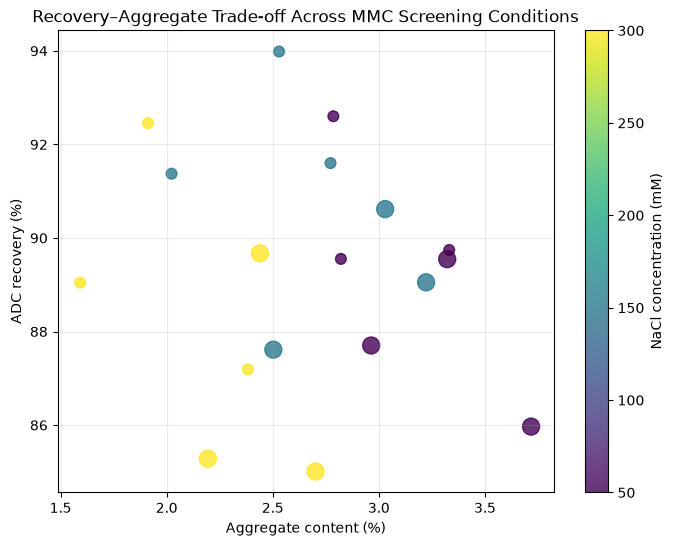

In [20]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    simulated["aggregate_percent"],
    simulated["recovery_percent"],
    c=simulated["NaCl_mM"],
    s=simulated["load_mg_per_mL_resin"] * 6,
    alpha=0.8
)

plt.xlabel("Aggregate content (%)")
plt.ylabel("ADC recovery (%)")
plt.title("Recovery–Aggregate Trade-off Across MMC Screening Conditions")

colorbar = plt.colorbar(scatter)
colorbar.set_label("NaCl concentration (mM)")

plt.grid(alpha=0.25)
plt.show()

In [21]:
promising_conditions = (
    simulated[
        [
            "pH",
            "NaCl_mM",
            "load_mg_per_mL_resin",
            "recovery_percent",
            "aggregate_percent",
            "mean_DAR",
        ]
    ]
    .sort_values(
        by=["recovery_percent", "aggregate_percent"],
        ascending=[False, True]
    )
    .round(2)
)

promising_conditions.head(10)

,pH,NaCl_mM,load_mg_per_mL_resin,recovery_percent,aggregate_percent,mean_DAR
8,6.5,150,10,93.99,2.53,4.00
6,6.5,50,10,92.60,2.79,4.02
10,6.5,300,10,92.45,1.91,3.96
2,5.5,150,10,91.60,2.77,4.00
14,7.5,150,10,91.37,2.02,3.98
9,6.5,150,25,90.62,3.03,4.01
0,5.5,50,10,89.74,3.33,4.08
11,6.5,300,25,89.67,2.44,3.93
12,7.5,50,10,89.55,2.82,4.05
7,6.5,50,25,89.55,3.32,4.06


### Evaluation of additional product-quality response

Recovery and aggregate content identify several promising process conditions,
but process selection should also consider whether the chromatography
conditions substantially affect the ADC product profile.

Mean DAR is therefore evaluated across the screening conditions to determine
whether the simulated chromatography parameters produce meaningful shifts
away from the target value of approximately 4.

Residual free drug-linker is not evaluated in this MMC analysis because its
clearance is modelled separately during the preceding UF/DF stage.

In [22]:
dar_summary = (
    simulated.groupby("pH")["mean_DAR"]
    .agg(["mean", "std"])
    .round(2)
)

dar_summary

,mean,std
pH,,
5.5,4.02,0.04
6.5,4.00,0.04
7.5,3.96,0.08


### Mean DAR analysis

Mean DAR remained close to the target value of approximately 4 across the
screened chromatography conditions.

Mean DAR changed only modestly across the evaluated pH range:

- pH 5.5: mean DAR 4.02
- pH 6.5: mean DAR 4.00
- pH 7.5: mean DAR 3.96

Within this simulated dataset, recovery and aggregate content provide stronger
differentiation between process conditions, while mean DAR remains
comparatively stable across the screening space.

Because these data are simulated, these trends represent assumptions built
into the process model rather than experimental evidence of specific
chromatographic mechanisms.

In [23]:
candidate_conditions = simulated[
    (simulated["recovery_percent"] >= 90) &
    (simulated["aggregate_percent"] <= 2.5)
].copy()

candidate_conditions = candidate_conditions.sort_values(
    by=["aggregate_percent", "recovery_percent"],
    ascending=[True, False]
)

candidate_conditions.round(2)

,pH,NaCl_mM,load_mg_per_mL_resin,recovery_percent,aggregate_percent,mean_DAR
10,6.5,300,10,92.45,1.91,3.96
14,7.5,150,10,91.37,2.02,3.98


### Preliminary process-condition selection

Applying the hypothetical screening criteria of at least 90% ADC recovery and
no more than 2.5% aggregate content reduced the 18-condition screening space
to two candidate conditions.

The candidate conditions were:

| pH | NaCl (mM) | Load (mg ADC/mL resin) | Recovery (%) | Aggregate (%) | Mean DAR |
|---:|---:|---:|---:|---:|---:|
| 6.5 | 300 | 10 | 92.45 | 1.91 | 3.96 |
| 7.5 | 150 | 10 | 91.37 | 2.02 | 3.98 |

Among these candidates, pH 6.5, 300 mM NaCl, and a load density of
10 mg ADC/mL resin provided the higher recovery and lower aggregate content.

The alternative condition at pH 7.5, 150 mM NaCl, and 10 mg ADC/mL resin
produced a mean DAR slightly closer to the target value of approximately 4,
but showed slightly lower recovery and higher aggregate content.

Therefore, pH 6.5, 300 mM NaCl, and 10 mg ADC/mL resin is selected as the
preferred condition for further evaluation within this simulated screening
study.

The screening thresholds used here are hypothetical project decision criteria
and should not be interpreted as universal ADC product specifications.

### Visualization of the process-selection window

The recovery–aggregate trade-off can also be evaluated against the hypothetical
screening criteria used for preliminary process selection.

Conditions located above the recovery threshold and below the aggregate
threshold satisfy both screening criteria.

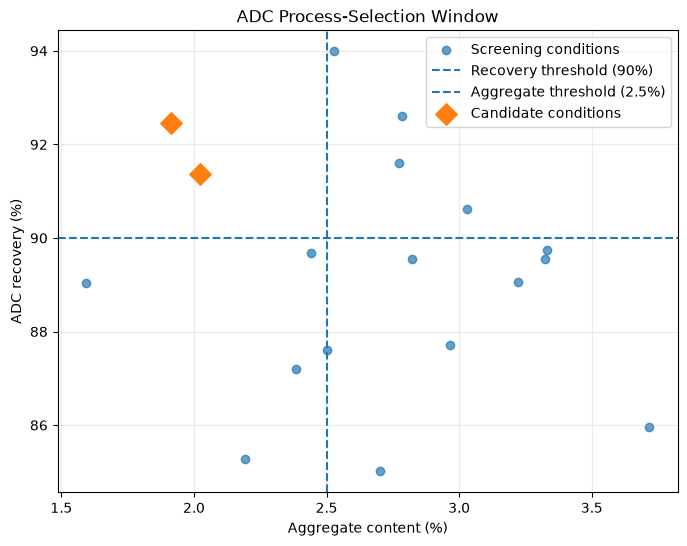

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    simulated["aggregate_percent"],
    simulated["recovery_percent"],
    alpha=0.7,
    label="Screening conditions"
)

plt.axhline(
    y=90,
    linestyle="--",
    label="Recovery threshold (90%)"
)

plt.axvline(
    x=2.5,
    linestyle="--",
    label="Aggregate threshold (2.5%)"
)

plt.scatter(
    candidate_conditions["aggregate_percent"],
    candidate_conditions["recovery_percent"],
    s=120,
    marker="D",
    label="Candidate conditions"
)

plt.xlabel("Aggregate content (%)")
plt.ylabel("ADC recovery (%)")
plt.title("ADC Process-Selection Window")

plt.legend()
plt.grid(alpha=0.25)
plt.show()

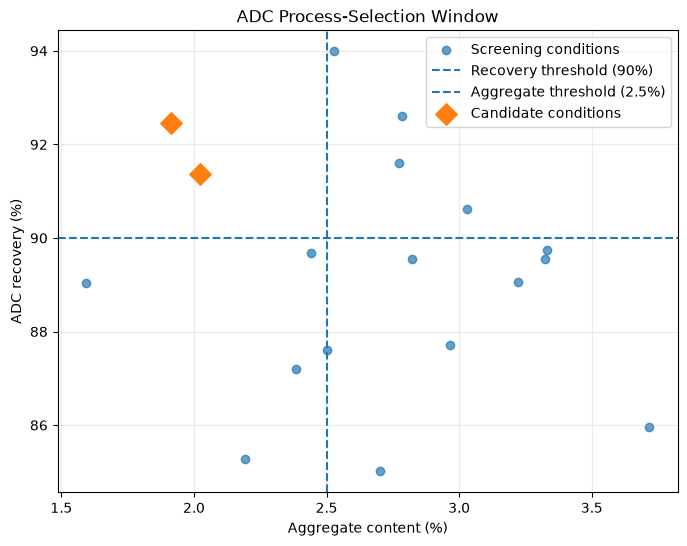

In [25]:
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

figure_file = FIGURES_DIR / "adc_process_selection_window.png"

plt.figure(figsize=(8, 6))

plt.scatter(
    simulated["aggregate_percent"],
    simulated["recovery_percent"],
    alpha=0.7,
    label="Screening conditions"
)

plt.axhline(
    y=90,
    linestyle="--",
    label="Recovery threshold (90%)"
)

plt.axvline(
    x=2.5,
    linestyle="--",
    label="Aggregate threshold (2.5%)"
)

plt.scatter(
    candidate_conditions["aggregate_percent"],
    candidate_conditions["recovery_percent"],
    s=120,
    marker="D",
    label="Candidate conditions"
)

plt.xlabel("Aggregate content (%)")
plt.ylabel("ADC recovery (%)")
plt.title("ADC Process-Selection Window")

plt.legend()
plt.grid(alpha=0.25)

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

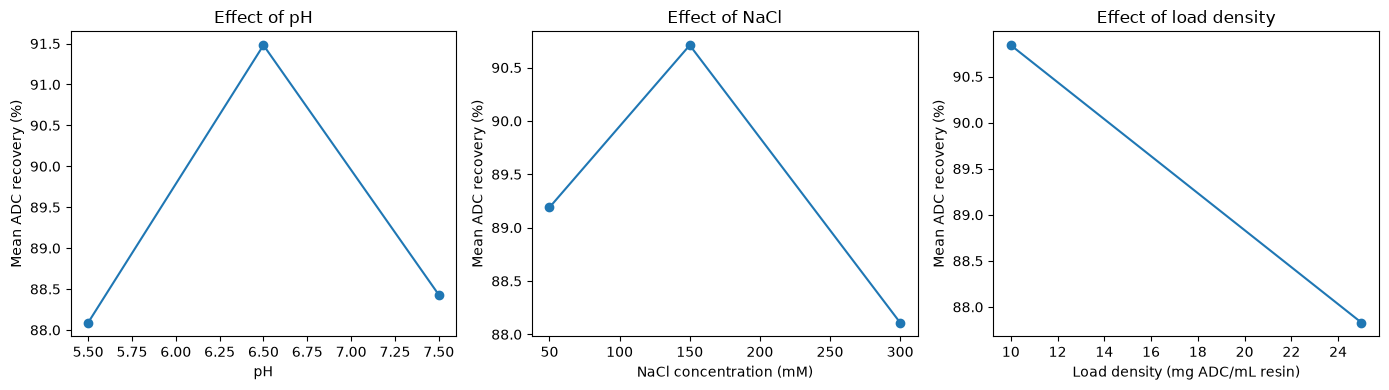

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(
    recovery_by_ph.index,
    recovery_by_ph["mean"],
    marker="o"
)
axes[0].set_xlabel("pH")
axes[0].set_ylabel("Mean ADC recovery (%)")
axes[0].set_title("Effect of pH")

axes[1].plot(
    recovery_by_salt.index,
    recovery_by_salt["mean"],
    marker="o"
)
axes[1].set_xlabel("NaCl concentration (mM)")
axes[1].set_ylabel("Mean ADC recovery (%)")
axes[1].set_title("Effect of NaCl")

axes[2].plot(
    recovery_by_load.index,
    recovery_by_load["mean"],
    marker="o"
)
axes[2].set_xlabel("Load density (mg ADC/mL resin)")
axes[2].set_ylabel("Mean ADC recovery (%)")
axes[2].set_title("Effect of load density")

plt.tight_layout()

main_effects_file = FIGURES_DIR / "adc_recovery_main_effects.png"

plt.savefig(
    main_effects_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()